In [1]:
import os
os.environ["OMP_NUM_THREADS"]="1"

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [3]:
df=pd.read_csv("smartcart_customers.csv")

In [4]:
df.isnull().sum()
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


# DATA PREPROCESSING

In [5]:
# 1. HANDLE MISSING VALUES
df["Income"]=df["Income"].fillna(df["Income"].median())

# Feature Engineering

In [6]:
# 1. Age
df["Age"]=2026-df["Year_Birth"]

# 2. Dt_Customer
df["Dt_Customer"]=pd.to_datetime(df["Dt_Customer"],dayfirst=True)
Reference=df["Dt_Customer"].max()
df["Customer_tenure_days"]=(Reference-df["Dt_Customer"]).dt.days

In [7]:
# 3. Num of children
df["Children"]=df["Kidhome"]+df["Teenhome"]

# 4. Total Spending
df["Total Spending"]=df["MntWines"]+df["MntFruits"]+df["MntMeatProducts"]+df["MntFishProducts"]+df["MntSweetProducts"]+df["MntGoldProds"]

# 5. Education
df["Education"]=df["Education"].replace({
    "PhD":"Postgraduate",
    "Master":"Postgraduate",
    "2n Cycle":"Undergraduate",
    "Basic":"Undergraduate",
    "Graduation":"Graduate"
})
df["Education"].value_counts()

# 6. Marital Status
df["Living_Status"]=df["Marital_Status"].replace({
    "Married" : "Partner",
    "Together":"Partner",
    "Single":"Alone",
    "Divorced":"Alone",
    "Widow":"Alone",
    "Absurd":"Alone",
    "YOLO":"Alone",
    
})

In [8]:
df.columns
df["Marital_Status"].value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

# Drop Columns

In [9]:
cols=["ID","Year_Birth","Marital_Status","Kidhome","Teenhome","Dt_Customer"]
spending_cols=["MntWines","MntFruits","MntMeatProducts","MntFishProducts","MntGoldProds","MntSweetProducts"]
cols_to_drop=cols+spending_cols
df_cleaned=df.drop(cols_to_drop,axis=1)

In [10]:
df_cleaned.columns

Index(['Education', 'Income', 'Recency', 'NumDealsPurchases',
       'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
       'NumWebVisitsMonth', 'Complain', 'Response', 'Age',
       'Customer_tenure_days', 'Children', 'Total Spending', 'Living_Status'],
      dtype='object')

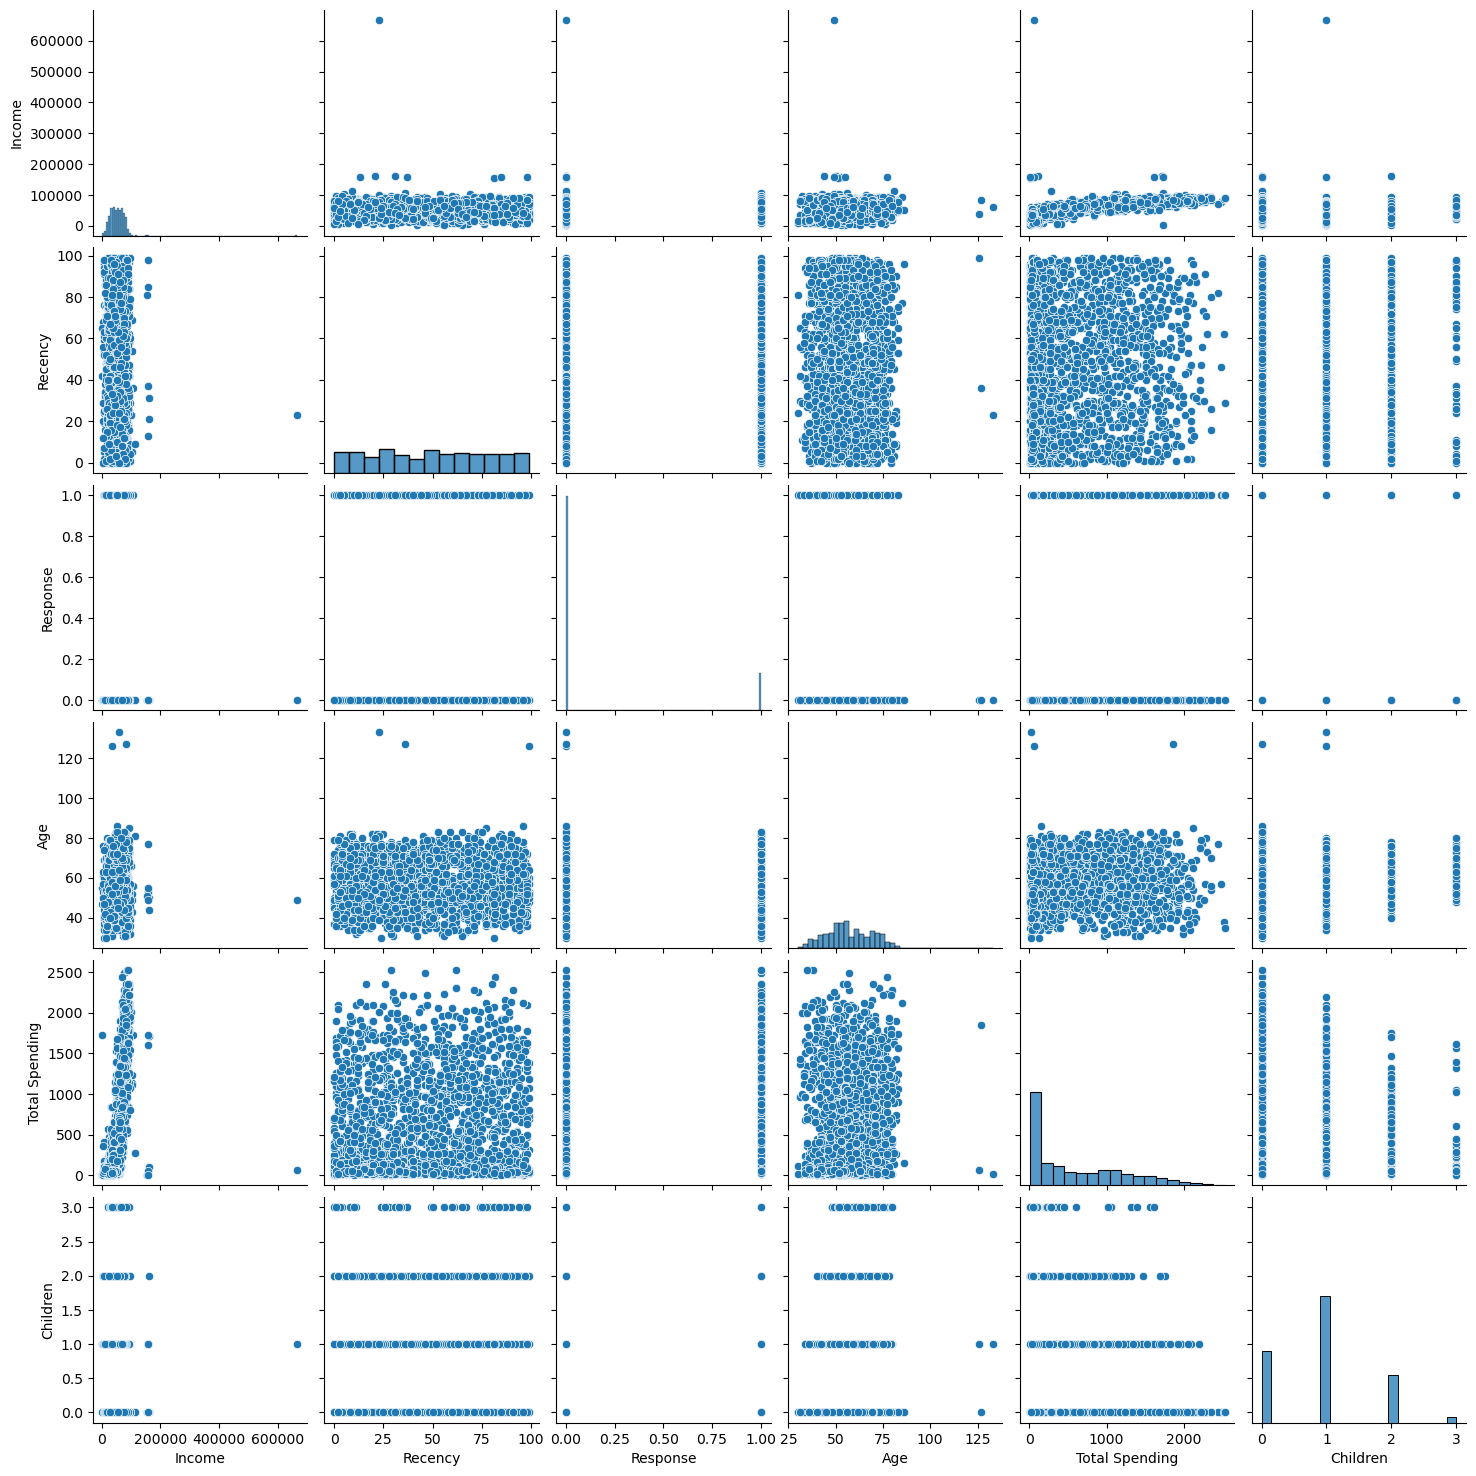

In [11]:
# Outlier Removal
cols=["Income","Recency","Response","Age","Total Spending","Children"]
sns.pairplot(df_cleaned[cols])

In [12]:
print("Data size with outlier : ",len(df_cleaned))

df_cleaned=df_cleaned[df_cleaned["Age"]<90]
df_cleaned=df_cleaned[df_cleaned["Income"]<600000]

print("Data size with outlier removal : ",len(df_cleaned))

Data size with outlier :  2240
Data size with outlier removal :  2236


# Heatmap

<Axes: >

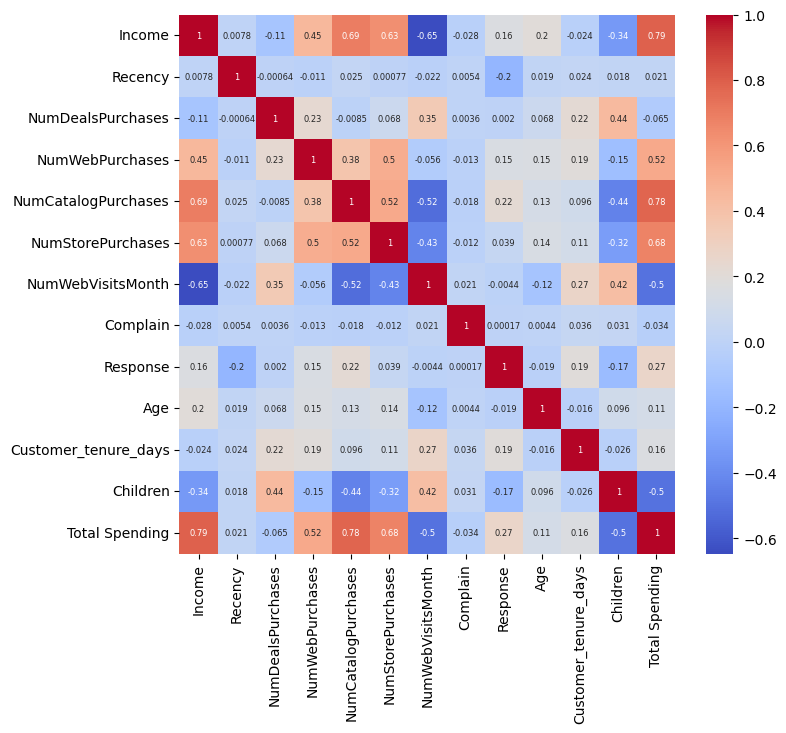

In [13]:
corr=df_cleaned.corr(numeric_only=True)
plt.figure(figsize=(8,7))
sns.heatmap(
    corr,
    annot=True,
    annot_kws={"size":6},
    cmap="coolwarm"
)

# Encoding

In [14]:
from sklearn.preprocessing import OneHotEncoder

ohe=OneHotEncoder()
cat_col=["Education","Living_Status"]
enc_col=ohe.fit_transform(df_cleaned[cat_col])
enc_df=pd.DataFrame(enc_col.toarray(), columns = ohe.get_feature_names_out(cat_col), index= df_cleaned.index)

In [15]:
df_encoded=pd.concat([df_cleaned.drop(columns=cat_col,axis=1),enc_df],axis=1)
df_encoded.shape

(2236, 18)

In [16]:
# Scaling
scaler=StandardScaler()
X=df_encoded
X_scaled=scaler.fit_transform(X)

# Visualization

In [51]:
from sklearn.decomposition import PCA
pca=PCA(n_components=3,random_state=42)
X_pca=pca.fit_transform(X_scaled)

In [52]:
pca.explained_variance_ratio_

array([0.23163158, 0.11385454, 0.10405815])

Text(0.5, 0.92, '3D view')

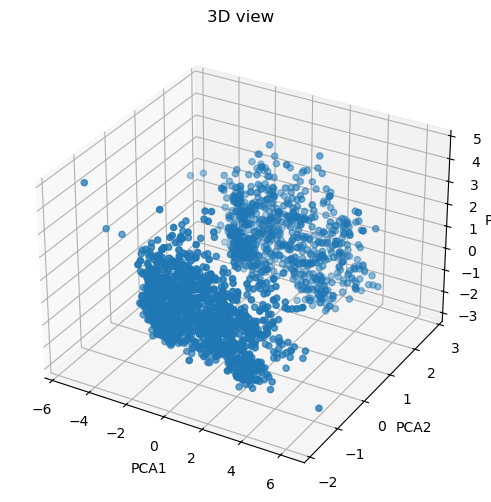

In [53]:
fig=plt.figure(figsize=(7,6))
ax=fig.add_subplot(111,projection="3d")
ax.scatter(
   X_pca[:,0],
   X_pca[:,1],
   X_pca[:,2]
   
)
ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3D view")

# Analyse K Value
## 1.Elbow Method

In [54]:
from sklearn.cluster import KMeans
from kneed import KneeLocator

wcss=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k)
    kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)

In [55]:
knee=KneeLocator(range(1,11),wcss,curve="convex",direction="decreasing")
optimal_k=knee.knee
print("Best K :",optimal_k)

Best K : 4


Text(0, 0.5, 'wcss')

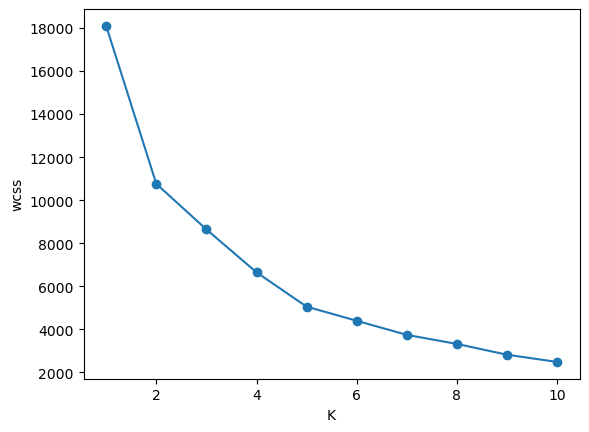

In [56]:
plt.plot(range(1,11),wcss,marker="o")
plt.xlabel("K")
plt.ylabel("wcss")


# 2. Silhouette

In [71]:
from sklearn.metrics import silhouette_score
scores=[]
for k in range(2,11):
    kmeans=KMeans(n_clusters=k,random_state=42)
    label=kmeans.fit_predict(X_pca)
    score=silhouette_score(X_pca,label)
    scores.append(score)

Text(0, 0.5, 'Silhouette score')

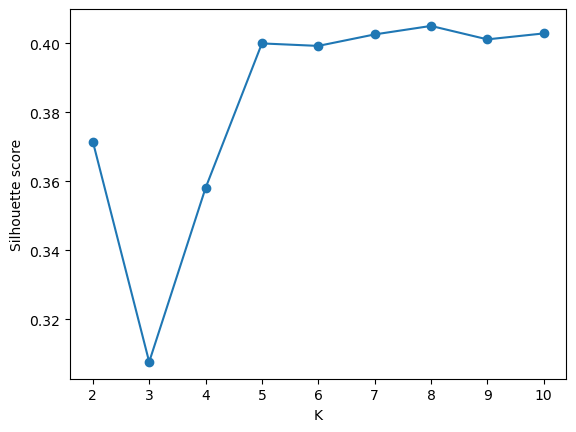

In [72]:
plt.plot(range(2,11),scores,marker="o")
plt.xlabel("K")
plt.ylabel("Silhouette score")

Text(0, 0.5, 'Silhouette score')

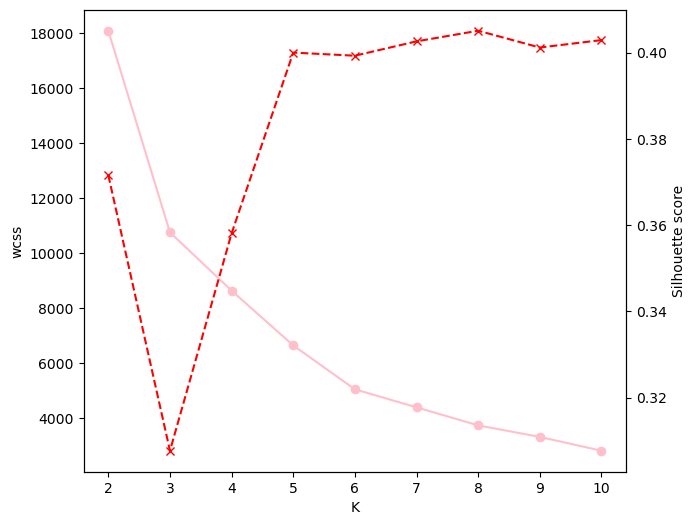

In [81]:
k_range=range(2,11)
fig,ax1=plt.subplots(figsize=(7,6))

ax1.plot(k_range,wcss[:len(k_range)],marker="o",color="pink")
ax1.set_xlabel("K")
ax1.set_ylabel("wcss")

ax2=ax1.twinx()
ax2.plot(k_range,scores[:len(k_range)],marker="x",color="red",linestyle="--")
ax2.set_xlabel("K")
ax2.set_ylabel("Silhouette score")

# CLUSTERING ALGO
## 1.KMeans

In [85]:
kmeans=KMeans(n_clusters=4,random_state=42)
label=kmeans.fit_predict(X_pca)

Text(0.5, 0.92, '3D view')

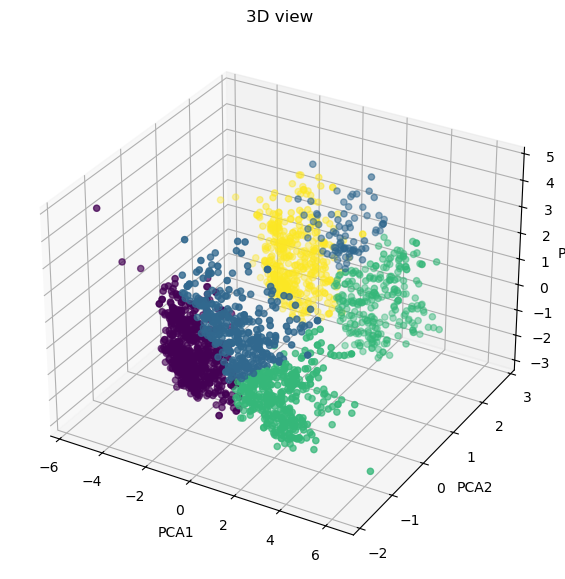

In [93]:
fig=plt.figure(figsize=(8,7))

ax=fig.add_subplot(111,projection="3d")

ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],c=label)
ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3D view")

## 2. Agglomerative Clustering

In [104]:
from sklearn.cluster import AgglomerativeClustering

agg_cls=AgglomerativeClustering(n_clusters=4,linkage="ward")
labels_agg=agg_cls.fit_predict(X_pca)

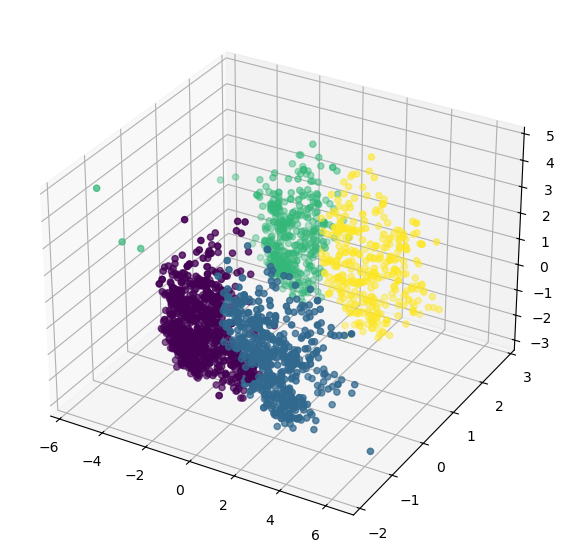

In [105]:
fig=plt.figure(figsize=(8,7))

ax=fig.add_subplot(111,projection="3d")

ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],c=labels)

# Characterisation of Clusters

In [122]:
X["Cluster"]=labels_agg

In [123]:
X

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_tenure_days,Children,Total Spending,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_Status_Alone,Living_Status_Partner,Cluster
0,58138.0,58,3,8,10,4,7,0,1,69,663,0,1617,1.0,0.0,0.0,1.0,0.0,3
1,46344.0,38,2,1,1,2,5,0,0,72,113,2,27,1.0,0.0,0.0,1.0,0.0,2
2,71613.0,26,1,8,2,10,4,0,0,61,312,0,776,1.0,0.0,0.0,0.0,1.0,1
3,26646.0,26,2,2,0,4,6,0,0,42,139,1,53,1.0,0.0,0.0,0.0,1.0,0
4,58293.0,94,5,5,3,6,5,0,0,45,161,1,422,0.0,1.0,0.0,0.0,1.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,61223.0,46,2,9,3,4,5,0,0,59,381,1,1341,1.0,0.0,0.0,0.0,1.0,0
2236,64014.0,56,7,8,2,5,7,0,0,80,19,3,444,0.0,1.0,0.0,0.0,1.0,0
2237,56981.0,91,1,2,3,13,6,0,0,45,155,0,1241,1.0,0.0,0.0,1.0,0.0,3
2238,69245.0,8,2,6,5,10,3,0,0,70,156,1,843,0.0,1.0,0.0,0.0,1.0,1


C:\Users\kashh\AppData\Local\Temp\ipykernel_21888\1255594893.py:3: UserWarning: The palette list has more values (5) than needed (4), which may not be intended.
  sns.countplot(x=X["Cluster"],palette=pal,hue=X["Cluster"])


<Axes: xlabel='Cluster', ylabel='count'>

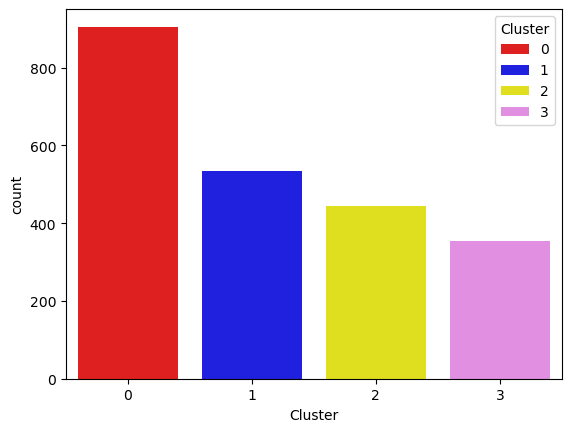

In [125]:
pal=["red","blue","yellow","violet","green"]

sns.countplot(x=X["Cluster"],palette=pal,hue=X["Cluster"])

# Income and Spending Patterns

C:\Users\kashh\AppData\Local\Temp\ipykernel_21888\1070247322.py:1: UserWarning: The palette list has more values (5) than needed (4), which may not be intended.
  sns.scatterplot(x=X["Total Spending"],y=X["Income"],hue=X["Cluster"],palette=pal)


<Axes: xlabel='Total Spending', ylabel='Income'>

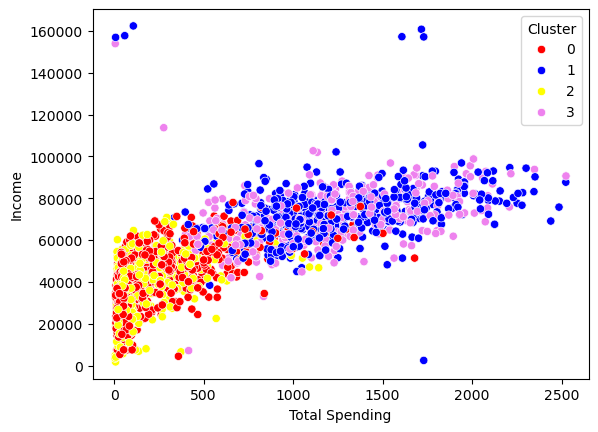

In [126]:
sns.scatterplot(x=X["Total Spending"],y=X["Income"],hue=X["Cluster"],palette=pal)

# Cluster Summary

In [131]:
cluster_summary=X.groupby("Cluster").mean()
print(cluster_summary)

               Income    Recency  NumDealsPurchases  NumWebPurchases  \
Cluster                                                                
0        39680.580110  48.914917           2.594475         3.153591   
1        72808.445693  49.202247           1.958801         5.687266   
2        36960.143018  48.319820           2.594595         2.713964   
3        70722.681303  50.504249           1.855524         5.790368   

         NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
Cluster                                                                        
0                   0.969061           4.143646           6.307182  0.011050   
1                   5.498127           8.659176           3.580524  0.005618   
2                   0.837838           3.623874           6.659910  0.011261   
3                   5.014164           8.430595           3.728045  0.005666   

         Response        Age  Customer_tenure_days  Children  Total Spending  \
Cluste